# Custom_CNN

In [1]:
import os   ### For working of CUDA 

# Disable XLA completely
os.environ["TF_XLA_FLAGS"] = "--tf_xla_auto_jit=0"
os.environ["XLA_FLAGS"] = "--xla_gpu_cuda_data_dir=/usr/local/cuda"
os.environ["TF_DISABLE_XLA"] = "1"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

In [2]:
import numpy as np
import pandas as pd
import cv2
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, roc_curve, auc, precision_score, recall_score, f1_score
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau


## Load Manifest

In [3]:
df = pd.read_csv("../data/processed/manifest.csv")
df.head()


,image_path,label,video_id,split
0,/home/aryan/code/DeepFakeDetection/data/proces...,0,183,train
1,/home/aryan/code/DeepFakeDetection/data/proces...,0,183,train
2,/home/aryan/code/DeepFakeDetection/data/proces...,0,183,train
3,/home/aryan/code/DeepFakeDetection/data/proces...,0,183,train
4,/home/aryan/code/DeepFakeDetection/data/proces...,0,183,train


## Verifiy no data leakage

In [4]:
dup = df.groupby("video_id")["split"].nunique()
print("Videos in multiple splits:")
print(dup[dup > 1])


Videos in multiple splits:
Series([], Name: split, dtype: int64)


## Load Images according to Split

In [5]:
def load_split(df, split):
    sub = df[df["split"] == split]
    images, labels = [], []

    for _, row in sub.iterrows():
        img = cv2.imread(row["image_path"])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (224, 224))
        images.append(img)
        labels.append(row["label"])

    return np.array(images), np.array(labels)

X_train, y_train = load_split(df, "train")
X_val,   y_val   = load_split(df, "val")
X_test,  y_test  = load_split(df, "test")


## Normalize + One-Hot Encoding

In [6]:
X_train = X_train / 255.
X_val   = X_val / 255.
X_test  = X_test / 255.  ## Softmax + categorical crossentropy requires one hot labels

y_train_cat = to_categorical(y_train, 2)  ## Before one hot --> [1,0,0,0,1,1,]
y_val_cat   = to_categorical(y_val, 2)      ## After one hot ---> [[1,0], [0,1]....]
y_test_cat  = to_categorical(y_test, 2)


## Data Augmentation (Important for small dataset)

In [7]:
datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

datagen.fit(X_train)


# Part A ---> Simple CNN

## Simple CNN Architecture

In [8]:
def build_simple():
    m = Sequential([
        Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
        MaxPooling2D(),

        Conv2D(64, (3,3), activation='relu'),
        MaxPooling2D(),

        Flatten(),
        Dense(64, activation='relu'),
        Dense(2, activation='softmax')
    ])

    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return m

simple_cnn = build_simple()
simple_history = simple_cnn.fit(
    datagen.flow(X_train, y_train_cat, batch_size=32),
    validation_data=(X_val, y_val_cat),
    epochs=15
)


/home/aryan/anaconda3/envs/DeepFakeDetection/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1764541891.028918  209664 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2605 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1650, pci bus id: 0000:01:00.0, compute capability: 7.5


Epoch 1/15


2025-12-01 04:01:35.845729: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-12-01 04:01:35.991845: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


 2/29 ━━━━━━━━━━━━━━━━━━━━ 2s 74ms/step - accuracy: 0.5078 - loss: 2.7505

I0000 00:00:1764541899.212254  209946 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


29/29 ━━━━━━━━━━━━━━━━━━━━ 17s 341ms/step - accuracy: 0.7200 - loss: 1.3191 - val_accuracy: 0.5000 - val_loss: 0.9062
Epoch 2/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 5s 182ms/step - accuracy: 0.7497 - loss: 0.4960 - val_accuracy: 0.5000 - val_loss: 0.7928
Epoch 3/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 5s 183ms/step - accuracy: 0.7982 - loss: 0.4025 - val_accuracy: 0.6029 - val_loss: 0.6227
Epoch 4/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 5s 171ms/step - accuracy: 0.8721 - loss: 0.3032 - val_accuracy: 0.5686 - val_loss: 0.7126
Epoch 5/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 5s 172ms/step - accuracy: 0.9195 - loss: 0.2224 - val_accuracy: 0.5000 - val_loss: 1.2893
Epoch 6/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 5s 160ms/step - accuracy: 0.9350 - loss: 0.1732 - val_accuracy: 0.5000 - val_loss: 1.9120
Epoch 7/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 5s 167ms/step - accuracy: 0.9361 - loss: 0.1679 - val_accuracy: 0.4804 - val_loss: 2.0907
Epoch 8/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 5s 167ms/step - accuracy: 0.9680 - loss: 0.1089 - val_accuracy: 0.5000 - val

## Evaluate

10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 150ms/step
Best threshold: inf
              precision    recall  f1-score   support

           0       0.64      1.00      0.78       193
           1       0.00      0.00      0.00       109

    accuracy                           0.64       302
   macro avg       0.32      0.50      0.39       302
weighted avg       0.41      0.64      0.50       302



/home/aryan/anaconda3/envs/DeepFakeDetection/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/aryan/anaconda3/envs/DeepFakeDetection/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/aryan/anaconda3/envs/DeepFakeDetection/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(

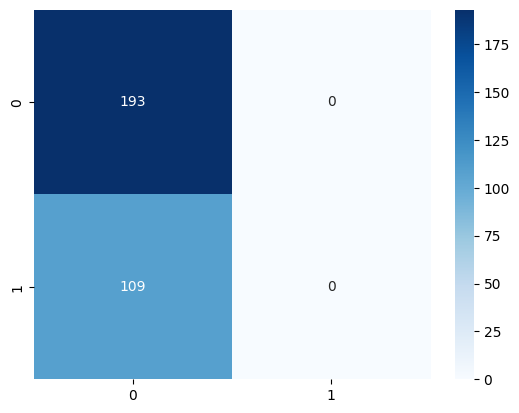

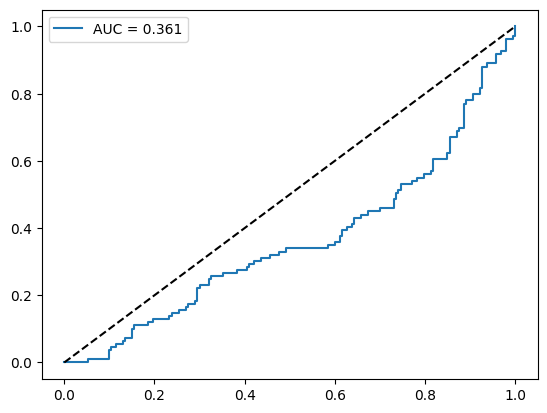

In [9]:
y_prob = simple_cnn.predict(X_test)[:,1]

fpr, tpr, thresh = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

best_idx = (tpr - fpr).argmax()
best_thresh = thresh[best_idx]
print("Best threshold:", best_thresh)

y_pred_opt = (y_prob >= best_thresh).astype(int)

print(classification_report(y_test, y_pred_opt))

cm = confusion_matrix(y_test, y_pred_opt)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.show()

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],'k--')
plt.legend()
plt.show()

# PART B --> Improved CNN (Bigger, Better Model)

## Improved CNN Architecture

In [10]:
def build_improved():
    m = Sequential([
        Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
        BatchNormalization(),
        MaxPooling2D(),

        Conv2D(64, (3,3), activation='relu'),
        BatchNormalization(),
        MaxPooling2D(),

        Conv2D(128, (3,3), activation='relu'),
        BatchNormalization(),
        MaxPooling2D(),

        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.4),
        Dense(2, activation='softmax')
    ])

    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return m

improved_cnn = build_improved()

improved_history = improved_cnn.fit(
    datagen.flow(X_train, y_train_cat, batch_size=32),
    validation_data=(X_val, y_val_cat),
    epochs=20
)


/home/aryan/anaconda3/envs/DeepFakeDetection/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 17s 380ms/step - accuracy: 0.8467 - loss: 3.4811 - val_accuracy: 0.5000 - val_loss: 22.1761
Epoch 2/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 5s 191ms/step - accuracy: 0.9372 - loss: 0.5273 - val_accuracy: 0.5000 - val_loss: 20.3504
Epoch 3/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 5s 183ms/step - accuracy: 0.9724 - loss: 0.1310 - val_accuracy: 0.5000 - val_loss: 14.8865
Epoch 4/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 5s 176ms/step - accuracy: 0.9691 - loss: 0.1618 - val_accuracy: 0.5000 - val_loss: 18.3474
Epoch 5/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 6s 193ms/step - accuracy: 0.9713 - loss: 0.0768 - val_accuracy: 0.5000 - val_loss: 7.2693
Epoch 6/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 6s 203ms/step - accuracy: 0.9581 - loss: 0.1350 - val_accuracy: 0.5000 - val_loss: 5.5240
Epoch 7/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 6s 190ms/step - accuracy: 0.9791 - loss: 0.0794 - val_accuracy: 0.5000 - val_loss: 3.7056
Epoch 8/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 5s 176ms/step - accuracy: 0.9636 - loss: 0.2481 - val_accurac

## Evaluate 

10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 133ms/step
Best threshold: 2.9031775e-33
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       193
           1       1.00      0.96      0.98       109

    accuracy                           0.99       302
   macro avg       0.99      0.98      0.99       302
weighted avg       0.99      0.99      0.99       302



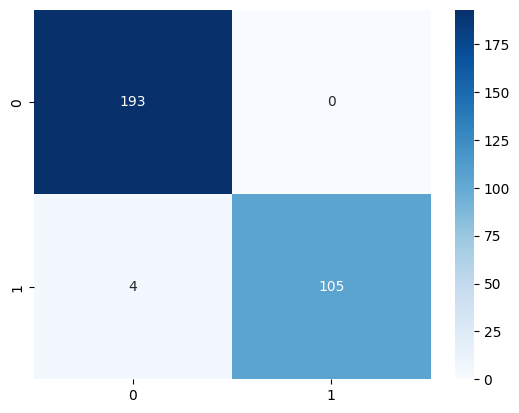

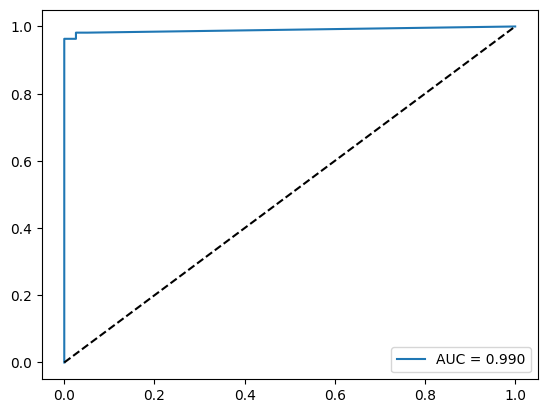

In [11]:
y_prob = improved_cnn.predict(X_test)[:,1]

fpr, tpr, thresh = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

best_idx = (tpr - fpr).argmax()
best_thresh = thresh[best_idx]
print("Best threshold:", best_thresh)

y_pred_opt = (y_prob >= best_thresh).astype(int)

print(classification_report(y_test, y_pred_opt))

cm = confusion_matrix(y_test, y_pred_opt)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.show()

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],'k--')
plt.legend()
plt.show()


## Plot histroy

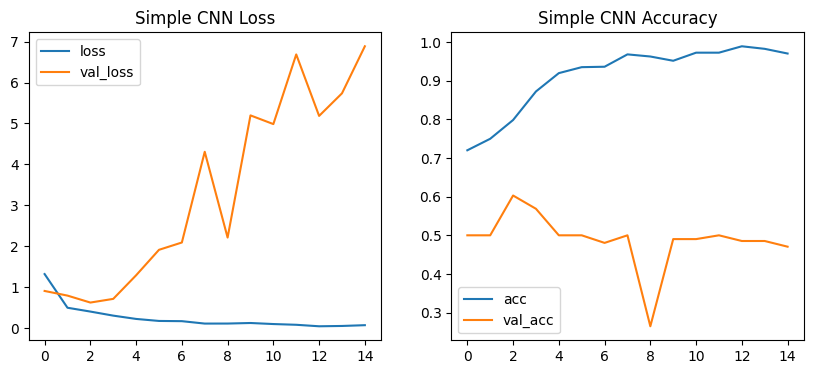

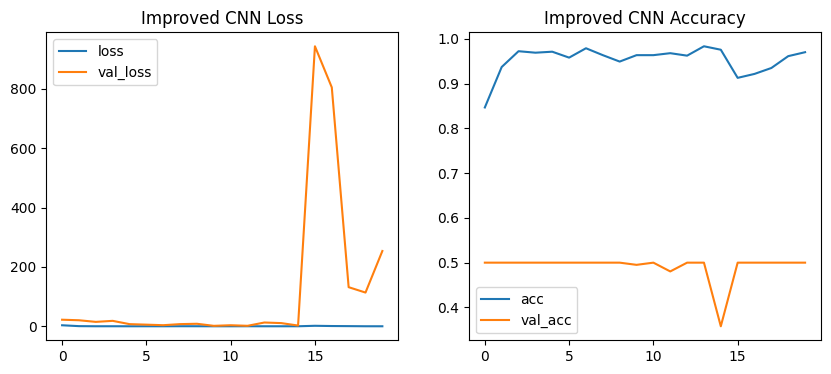

In [12]:
def plot_history(h, title):
    plt.figure(figsize=(10,4))
    
    plt.subplot(1,2,1)
    plt.plot(h.history['loss'], label='loss')
    plt.plot(h.history['val_loss'], label='val_loss')
    plt.title(title + ' Loss')
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(h.history['accuracy'], label='acc')
    plt.plot(h.history['val_accuracy'], label='val_acc')
    plt.title(title + ' Accuracy')
    plt.legend()
    plt.show()

plot_history(simple_history, "Simple CNN")
plot_history(improved_history, "Improved CNN")


## Simple CNN
* Traning
   * loss dropping close to 0
   * accuracy climbing to almost 1
#### Model memorized the training images

* Validation
    * loss increasing steadily
    * Accuracy stuck around 0.5

#### Model cannot predict new images --> random guessing



## Improved CNN /// Even worse in this case 
* Same issue
* Improved model is memorizing even harder

## CNN from scratch fails for deepfake detection as 
* data set is too small
* Too much varience in faces
* high frequency signals
* Overfits instantly
* Validation accuracy collapes  /// classic behavior for CNN models on small dataset

## Transfer Learning is important